## **<center>New York Yellow Taxi</center>**
### **<center>Analysis Project</center>**
#### **<center>Part Two</center>**




----

## Executive Summary 

This project analyzes New York City Yellow Taxi trip data from 2020, a year heavily disrupted by the COVID-19 pandemic. Using operational trip-level data—including passenger counts, fares, trip distances, pickup times, and payment methods—the analysis explores how taxi demand and fare behavior changed during this period. Through exploratory analysis, statistical testing, and regression modeling, the project identifies strong temporal patterns, meaningful differences across passenger groups, and robust relationships between trip characteristics and total fare amounts. Overall, the findings highlight how even during extreme disruptions, core travel behaviors such as time-of-day demand and fare structure remained surprisingly consistent, offering insight into the resilience of urban transportation systems. 

## Table of Contain

1. Introduction

2. Problem Statement
   
3. Upload the Dataset

4. Data Cleaning

5. Exploratory Data Analysis (EDA)

6. Statistical Testing and Modeling

7. Validation and Interpretation

8. Discussion and Limitations

9. Conclusion

10. References


## 1. Introduction


Taxis are an essential part of urban transportation and are used on a daily basis all around the world. They are quick and comfortable but more expensive compared to public transportation such as trams and buses.

In this project, we analyze and interpret New York City Yellow Taxi data from 2020, a year considered particularly challenging and less busy for taxi drivers due to the COVID-19 pandemic. Various aspects of Yellow Taxi operations are examined, including pickup and drop-off times, number of passengers, trip distances, payment types, and total fares, among others.

To gain insights from this dataset, various statistical models and tests are applied to uncover patterns, identify relationships, analyze correlations, and make predictions. 

## 2. Problem Statement

This project seeks to thoroughly explore and analyze NYC taxi trip data, revealing key patterns in trip characteristics such as trip distances and durations, cash vs. card payments, and typical fares with surcharges. We'll start with exploratory data analysis to reveal initial trends, then dig deeper using statistical tests and models. The main goal is to deliver clear descriptive insights on how taxis are used by different passengers at various times, plus apply those statistical tools to uncover relationships between variables and see how they influence one another.


## 3. Uploading the Dataset

In [51]:
import pandas as pd
import numpy as np
import pyarrow
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

nytaxi = pd.read_parquet(r"E:\Python environments\nytaxi.parquet")


## 4. Data cleaning

The dataset used in this analysis was pre-cleaned as part of a prior project (New York Yellow Taxi, Part 1).
That process included handling missing values, correcting data types, and removing invalid records.
No additional data cleaning steps were required beyond those performed in Part 1 for the scope of the current analysis.

## 5. Exploratory Data Analysis (EDA)

### Summary Statistics

In [52]:
summary_stats = nytaxi[['passenger_count',
            'trip_distance',
            'fare_amount',
            'tip_amount',
            'tolls_amount', 
            'total_amount'
]]
summary_stats.describe().round(2)


Column,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount
count,22761013.0,22761013.00,22761013.00,22761013.00,22761013.00,22761013.00
mean,1.41,2.73,12.09,2.09,0.26,17.85
std,0.9,3.46,10.62,2.39,1.35,12.83
min,1.0,0.00,2.00,0.00,0.00,2.00
25%,1.0,0.97,6.50,0.00,0.00,11.15
50%,1.0,1.60,9.00,1.92,0.00,14.16
75%,1.0,2.88,13.50,2.85,0.00,19.30
max,5.0,98.56,300.00,50.00,20.00,340.30


* This summary covers 22.7 million NYC taxi trips and shows very typical riding and payment patterns. Most rides are single-passenger and short, with trip distances usually under 3 miles, which keeps fares relatively low. The typical fare is around 9–14 USD, while the average is higher due to a small number of long or expensive trips. Tips vary widely—many riders leave no tip, while others tip modestly, with only a few very large tips pushing up the maximum. Tolls appear infrequently, as most trips don’t involve toll roads. Overall, total trip costs usually fall in the 10–20 USD range, with a handful of high-cost outliers, reflecting realistic and consistent NYC taxi behavior.


**Correlation Matrix**

*passenger_count, trip_distance, fare_amount, total_amount*

In [53]:
corr_matrix = nytaxi[
    ['passenger_count', 'trip_distance', 'fare_amount', 'total_amount']
].corr().round(2)

corr_matrix.index.name = "Row variable"
corr_matrix.columns.name = "Column variable"

corr_matrix.style.background_gradient(cmap="viridis")

Column variable,passenger_count,trip_distance,fare_amount,total_amount
Row variable,,,,
passenger_count,1.000000,0.010000,0.010000,0.010000
trip_distance,0.010000,1.000000,0.880000,0.880000
fare_amount,0.010000,0.880000,1.000000,0.980000
total_amount,0.010000,0.880000,0.980000,1.000000


* This correlation matrix shows that passenger count has almost no relationship with distance or cost, meaning the number of riders doesn’t meaningfully affect how far a taxi travels or how much it costs. In contrast, trip distance is strongly correlated with both fare amount and total amount, which makes sense since longer trips naturally lead to higher fares. The strongest relationship appears between fare amount and total amount, indicating that the base fare is the primary driver of the final trip cost. Overall, the relationships are intuitive and consistent with real-world taxi pricing.

### Visualizations

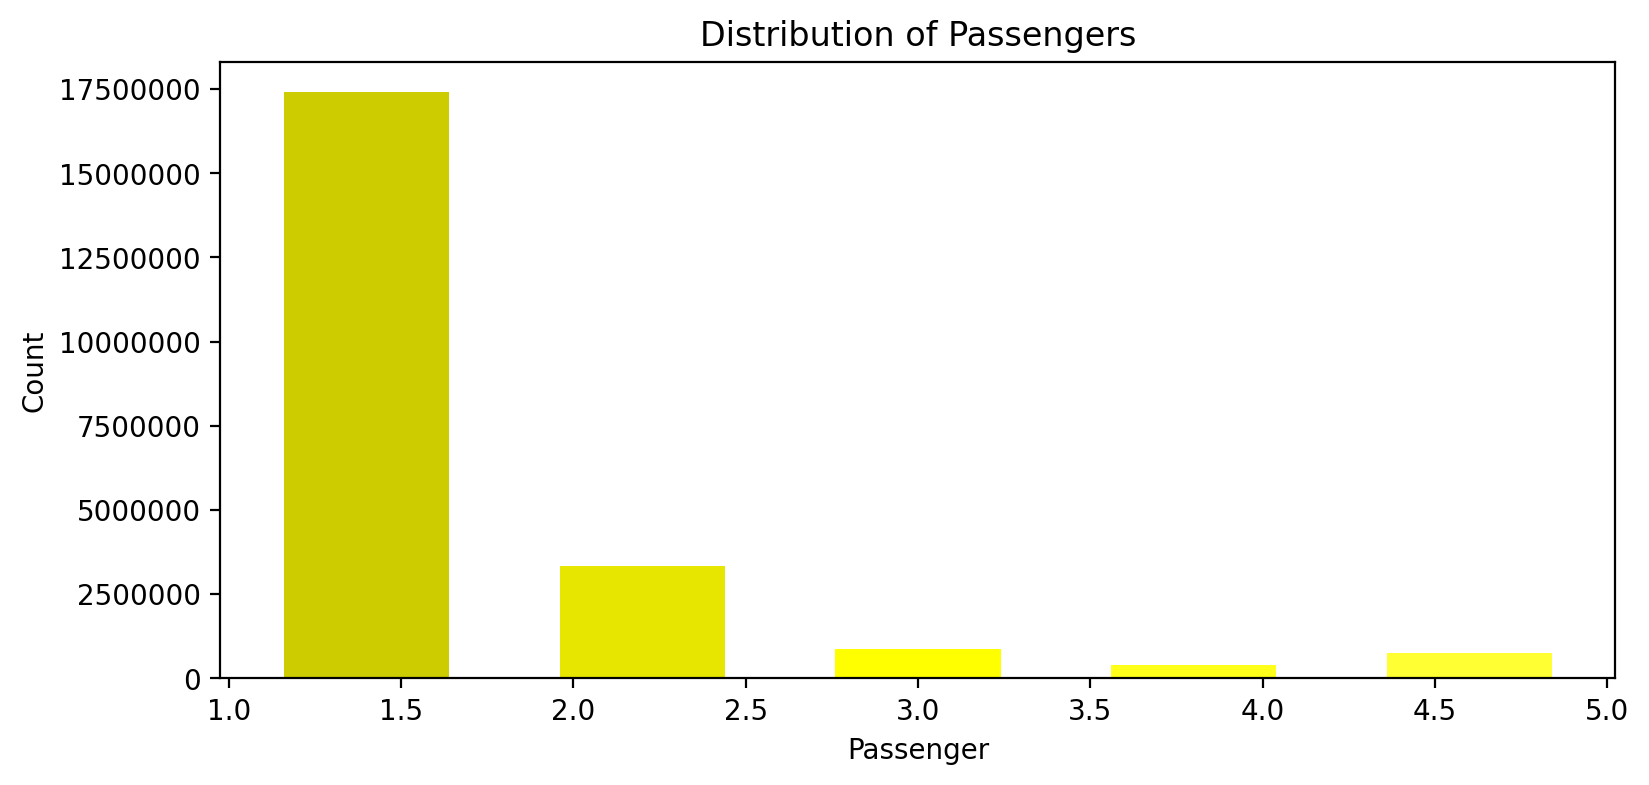

In [54]:
import matplotlib.pyplot as plt

colors = ['#cccc00', '#e6e600', '#ffff00', '#ffff1a', '#ffff33']

plt.figure(figsize=(9, 4), dpi=200)


n, bins, patches = plt.hist(
    nytaxi.passenger_count,
    bins=5,
    rwidth=0.6
)

for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

plt.ticklabel_format(style='plain', axis='y')
plt.title('Distribution of Passengers')
plt.xlabel('Passenger')
plt.ylabel('Count')
plt.show()


* The distribution of the passenger indicate that the most of the passenger ride dominate with solo traveler.

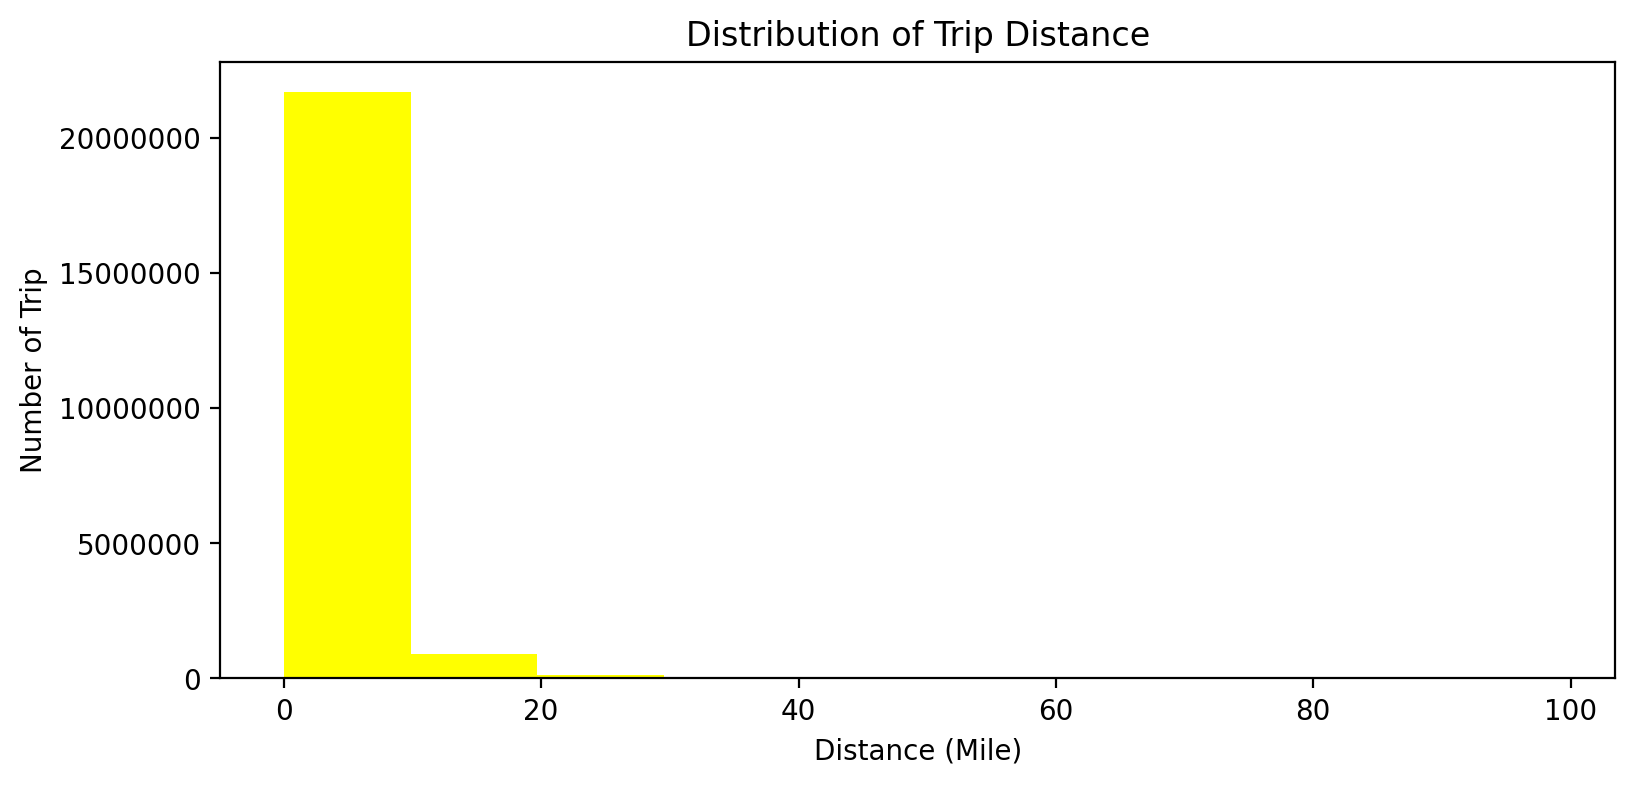

In [55]:
plt.figure(figsize=(9,4), dpi=200)
plt.hist(nytaxi.trip_distance, 
         color='yellow')
plt.title('Distribution of Trip Distance')
plt.xlabel('Distance (Mile)')
plt.ylabel('Number of Trip')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

* Distances that vast majority of passengers travel is between 1 to 10 miles. However, travel long distance is possible but rare.

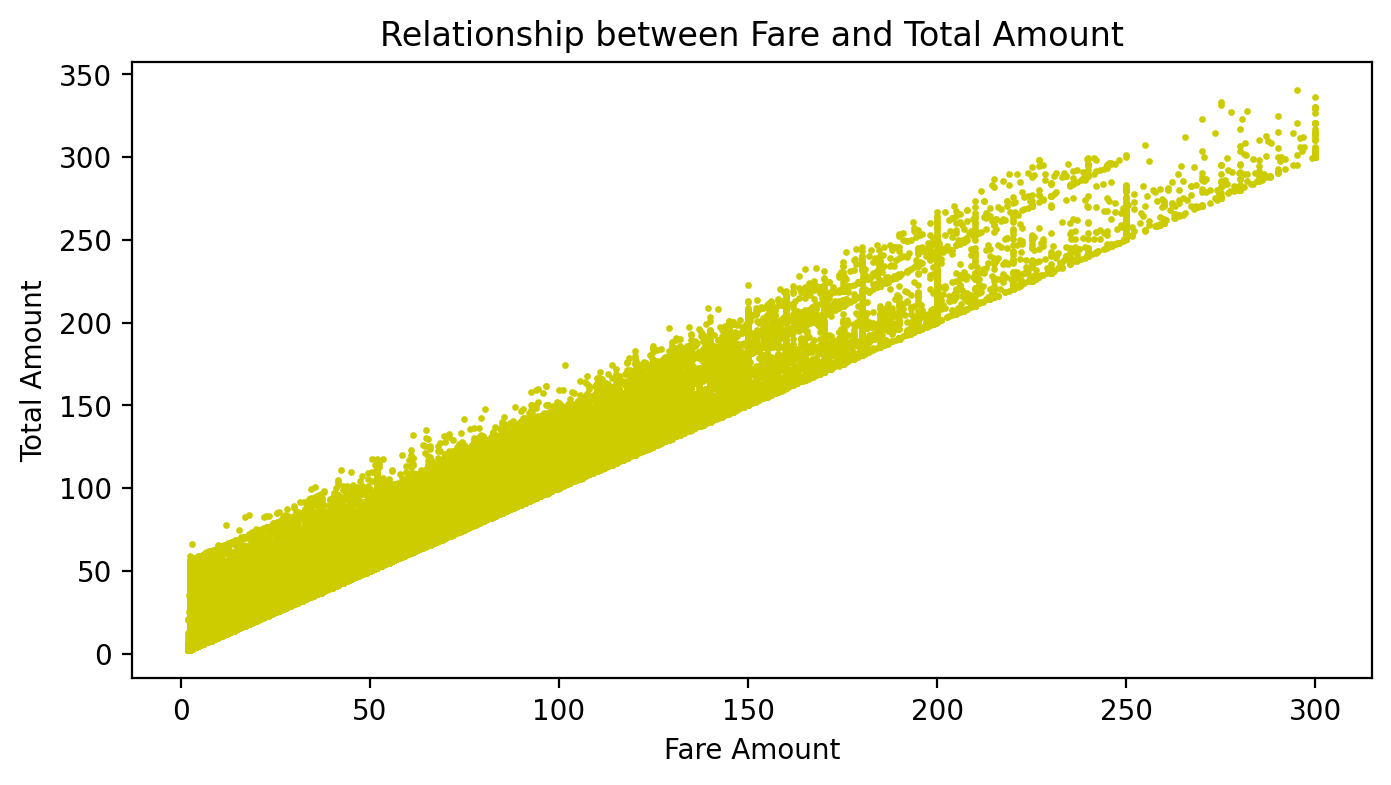

In [56]:
plt.figure(figsize=(8,4), dpi=200)
plt.scatter(x=nytaxi.fare_amount, 
            y=nytaxi.total_amount, 
            color="#cccc00",
           s=2
           )

plt.title('Relationship between Fare and Total Amount')
plt.xlabel('Fare Amount')
plt.ylabel('Total Amount')
plt.show()

* This graph shows clearly that there is a strongest relationship between fare amount and total amount. Meaning, the total amount is almost entirely driven by the fare itself. 

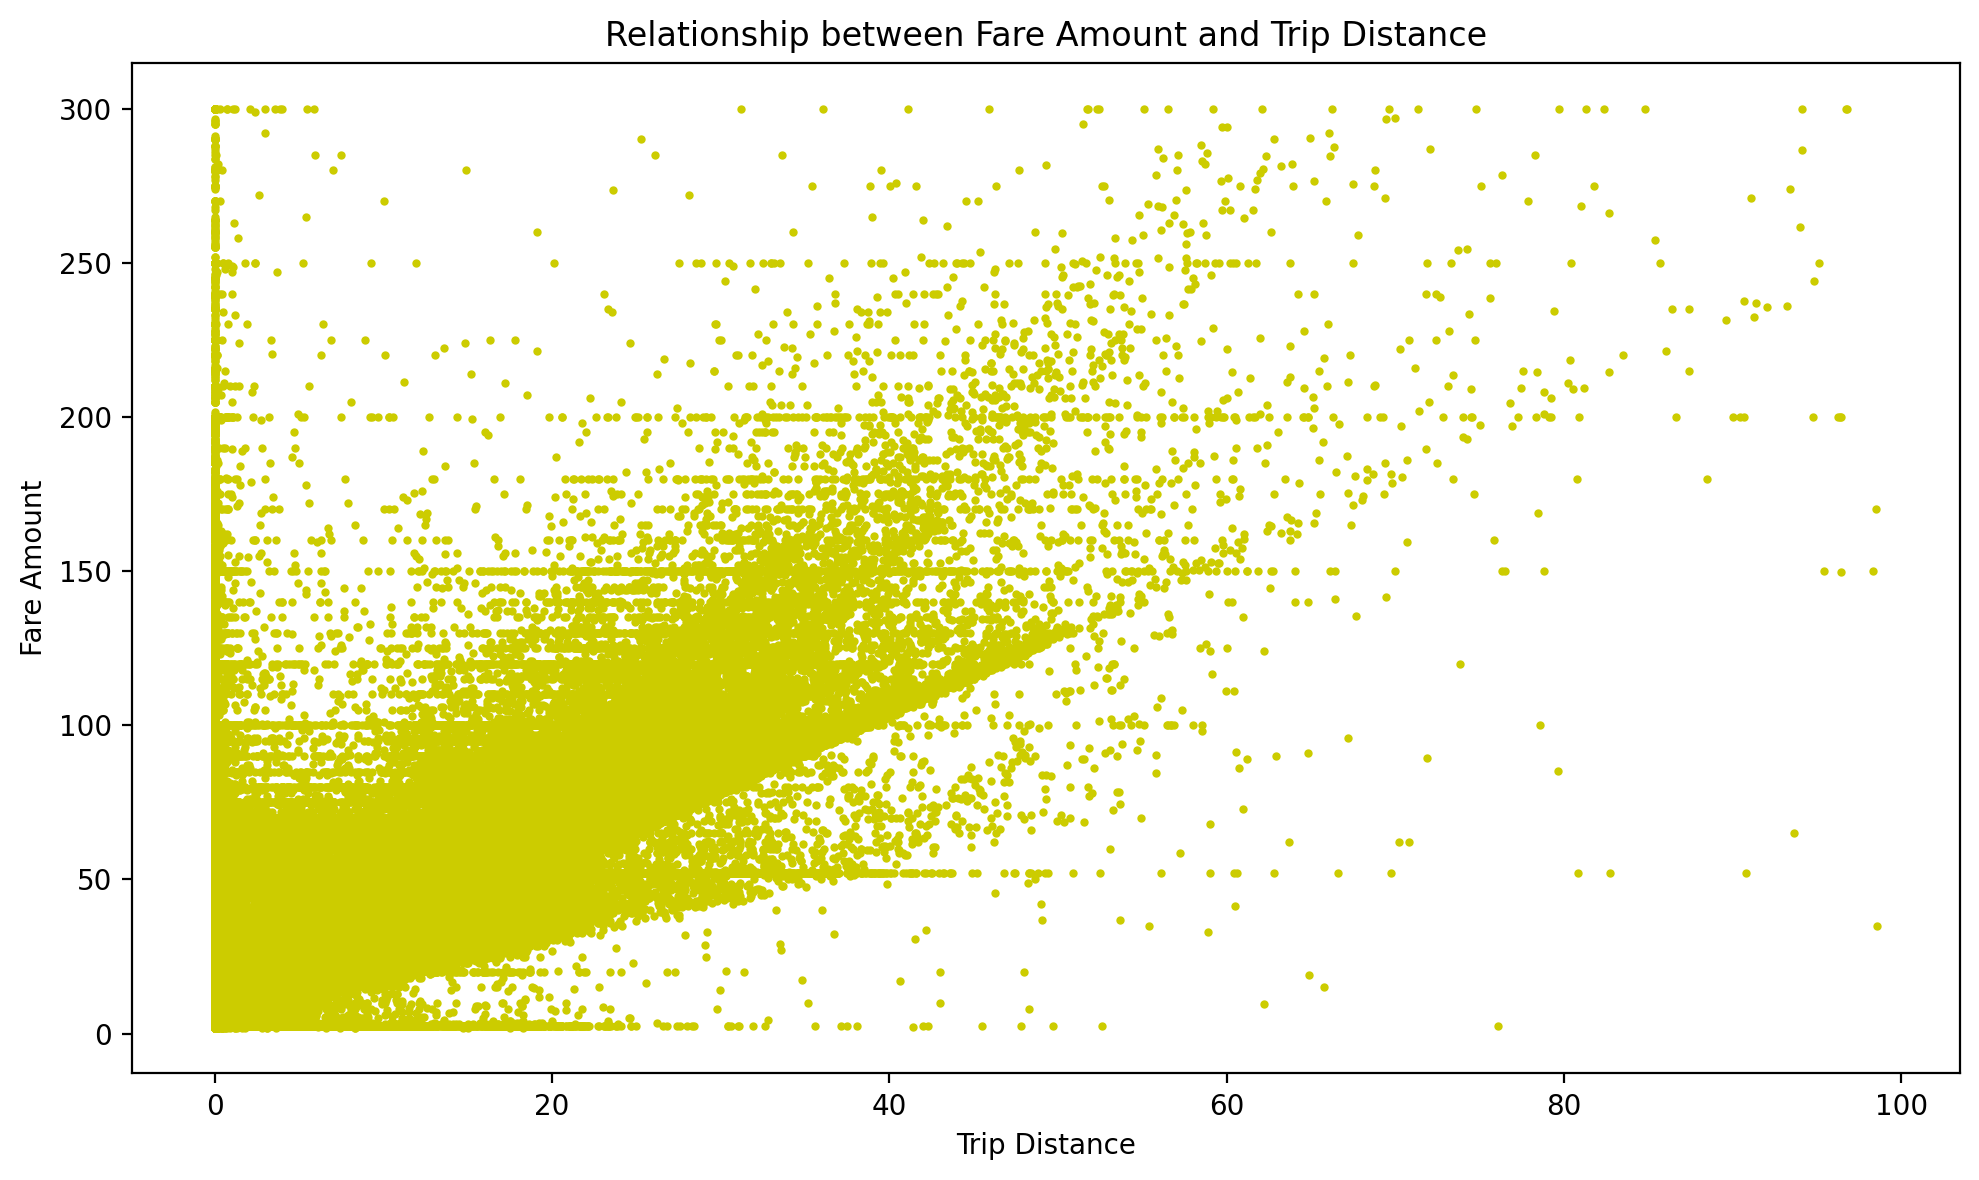

In [57]:
plt.figure(figsize=(10,6), dpi=200)
plt.scatter(x=nytaxi.trip_distance, 
            y=nytaxi.fare_amount, 
            color='#cccc00',
            s=4            
           )

plt.title('Relationship between Fare Amount and Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.tight_layout()
plt.show()

* It is seen a strong positive correlation with fare amount and trip distance. It means, fares generally increase as distance increases. Long trips tend to cost more, and distance is a big factor in how fares are calculated.

* At the first glance, outliers are visible in the scatter plot. However, given that trip_distance is validated between 0 and 100 miles and fare_amount between 2 and 300 USD, the few high-distance or high-fare observations seen in the data are unusual but still plausible within the context of NYC yellow taxi trips such as airport trips, traffic delays, and tolls. Therefore, these points should not be treated as outliers or errors but legitimate edge cases.


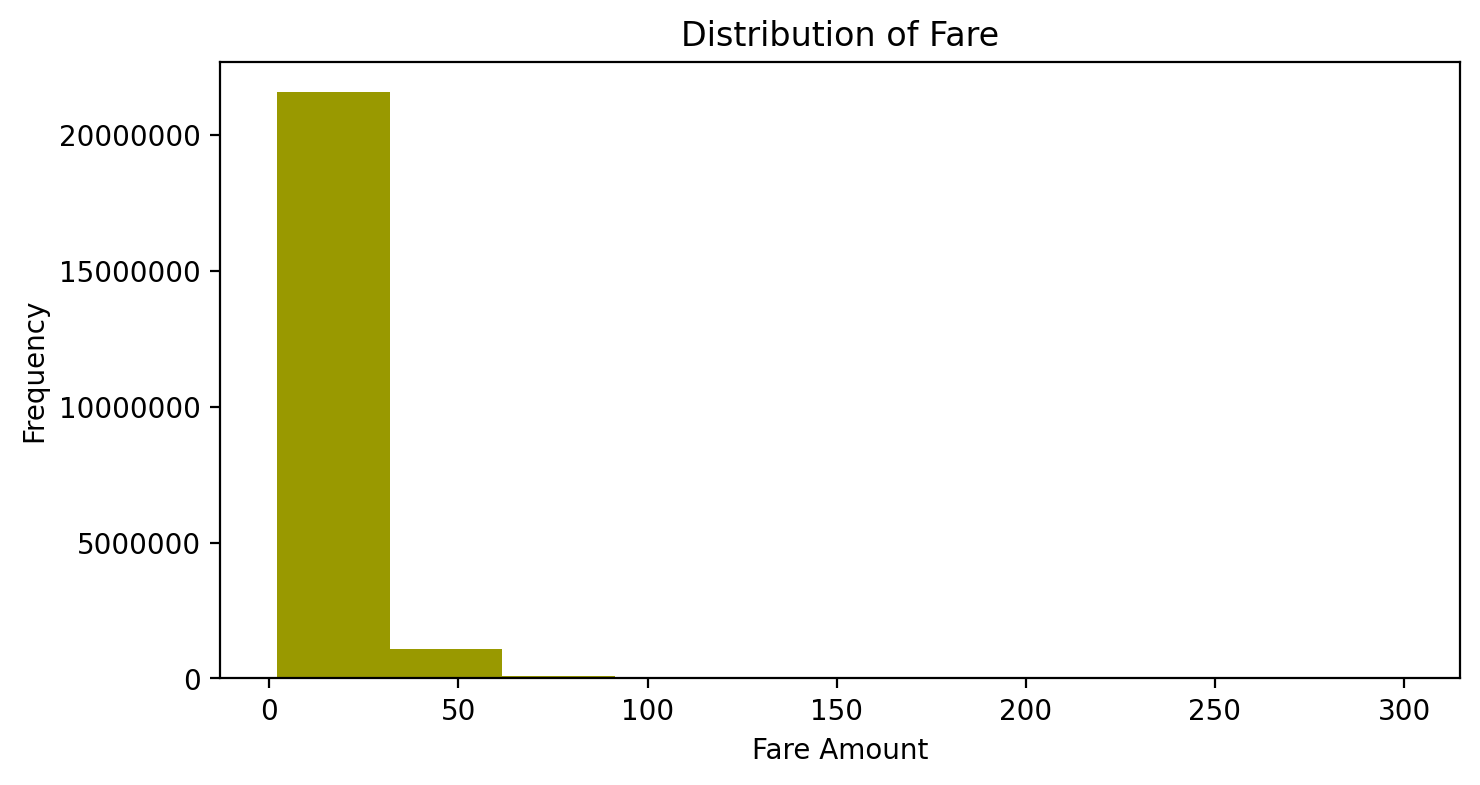

In [58]:
plt.figure(figsize=(8,4), dpi=200)

nytaxi['fare_amount'].plot(kind='hist', color='#999900')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Distribution of Fare')
plt.xlabel('Fare Amount')
plt.show()

* Taxi fares range from 2 to 300 USD and show a clear right-skewed distribution. Most trips cluster between about 5 and 45 USD, reflecting the dominance of short to medium-distance rides in NYC. The long right tail comes from a small number of high-fare trips, which, while less common, are still realistic—such as airport runs, long-distance rides, tolls, or delays caused by traffic. As a result, the right-skewed pattern reflects normal taxi usage rather than data errors.

### Log-Transformation

Since some variables are far right-skewed, we apply log-tranformation on them to assess how the right-skewed dataset react to log-transformation and whether is it an appropriate approach to apply to dataset

**passenger_count**

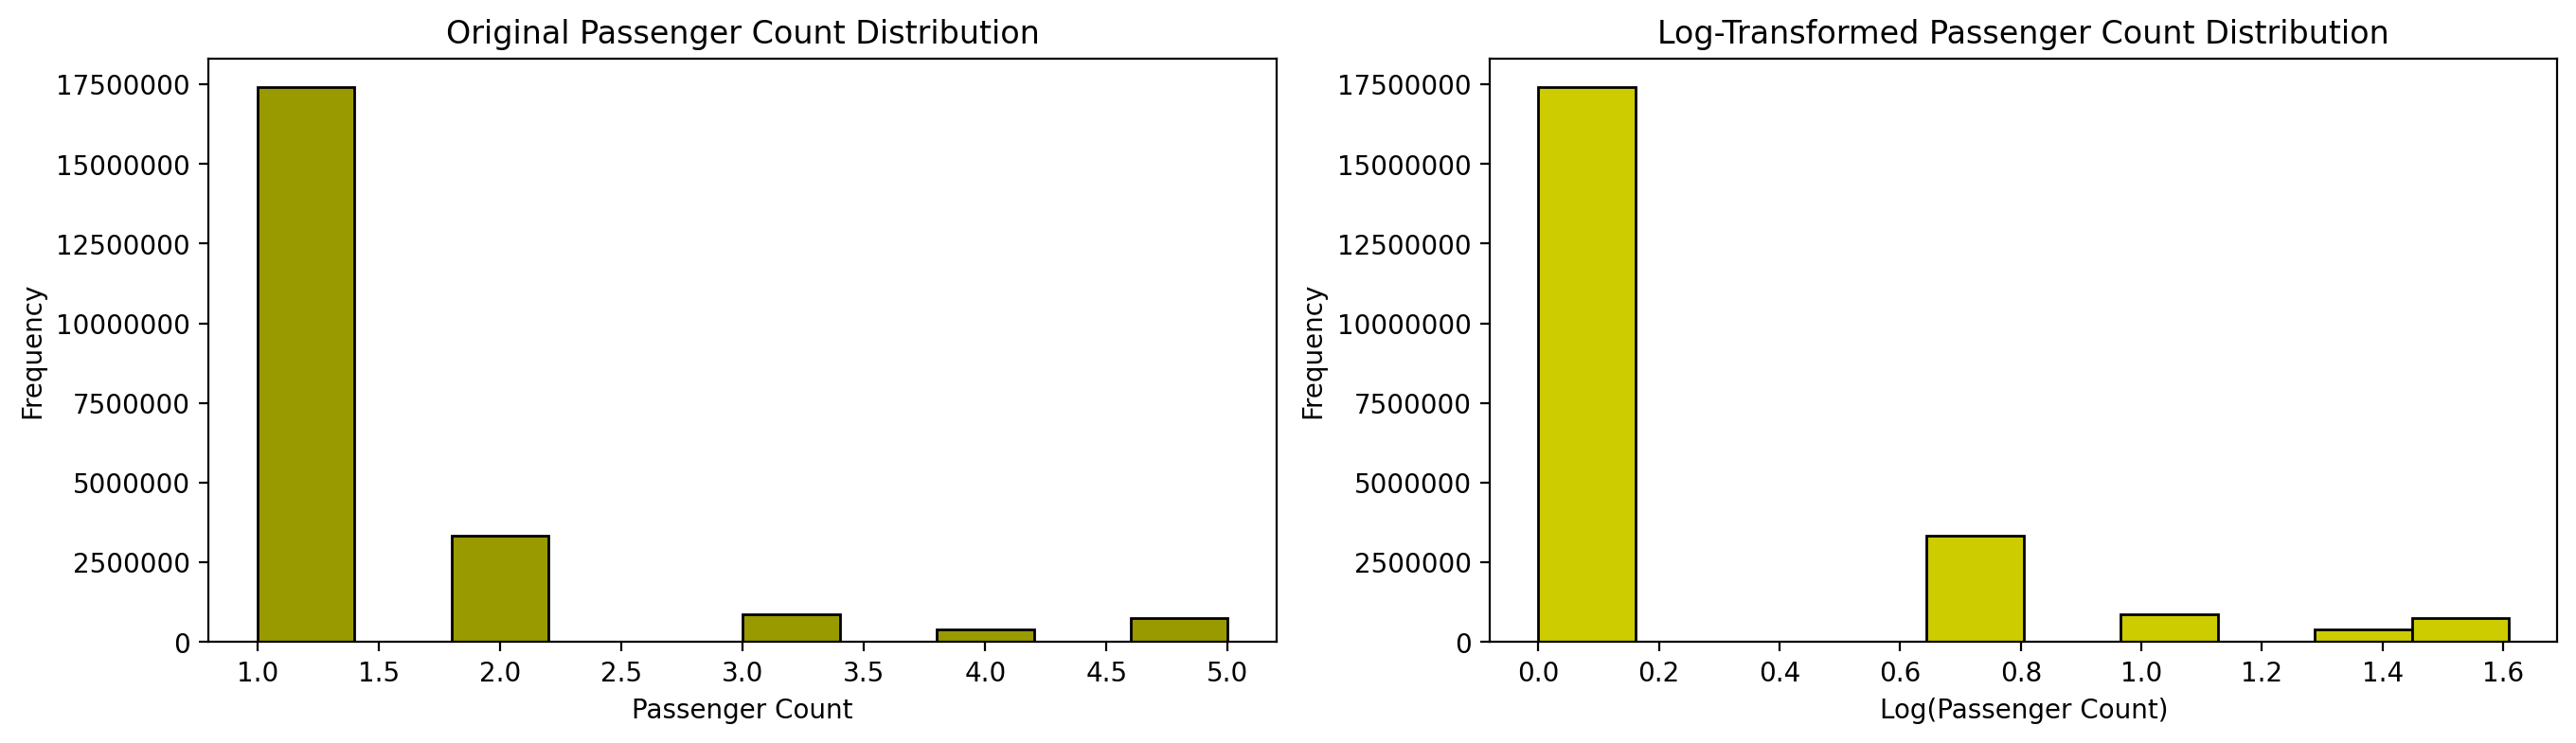

In [59]:
passenger_count_log = np.log(nytaxi['passenger_count'])

fig, axs = plt.subplots(1, 2, figsize=(16, 4), dpi=200)


axs[0].hist(nytaxi.passenger_count, edgecolor='black', color='#999900')
axs[0].set_title('Original Passenger Count Distribution')
axs[0].set_xlabel('Passenger Count')
axs[0].set_ylabel('Frequency')
axs[0].ticklabel_format(style='plain', axis='y')


axs[1].hist(passenger_count_log, edgecolor='black', color='#cccc00')
axs[1].set_title('Log-Transformed Passenger Count Distribution')
axs[1].set_xlabel('Log(Passenger Count)')
axs[1].set_ylabel('Frequency')
axs[1].ticklabel_format(style='plain', axis='y')

plt.show()


The result is as expected. The log transformation is not appropriate or even useful for a variable that is bounded or discrete, such as *passenger_count*, because it only ranges from 1 to 5. Therefore, applying a log transformation to such a small range cannot meaningfully reduce the right skewness of the data and it was retained in its original scale for subsequent analysis.


**trip_distance**

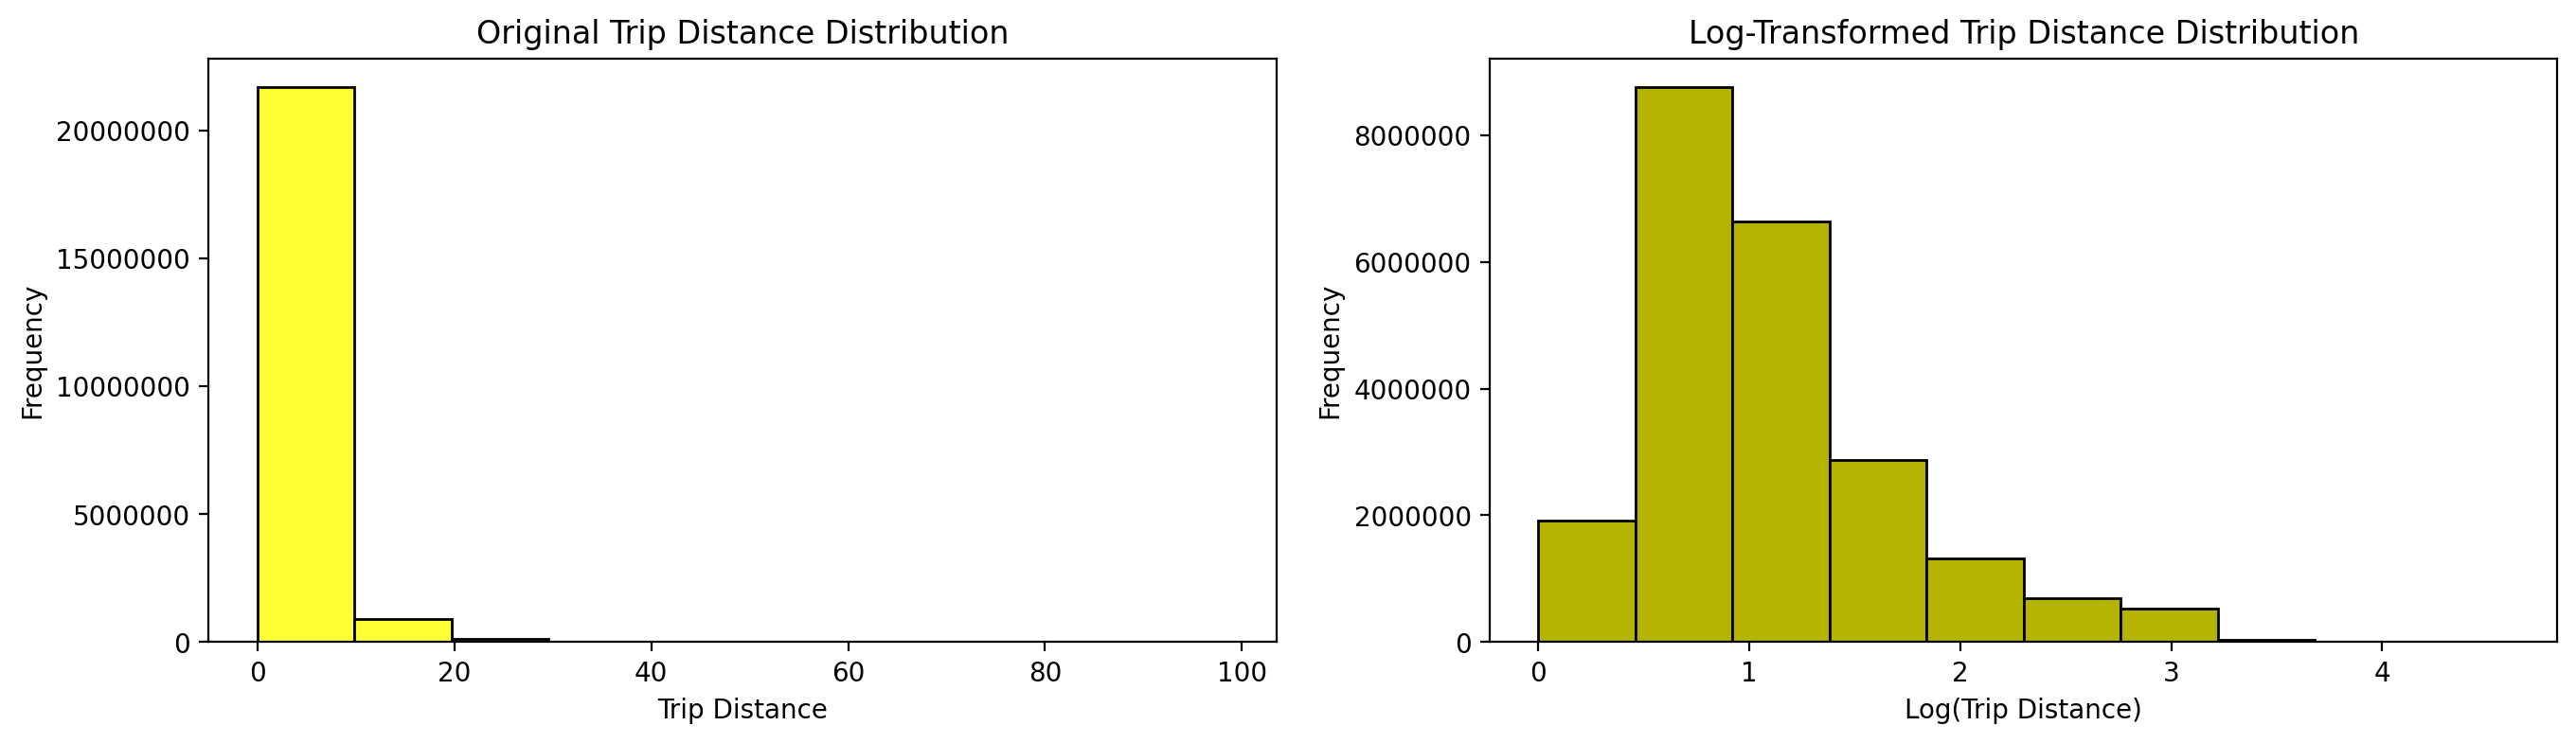

In [60]:
trip_distance_log = np.log(nytaxi['trip_distance'] + 1)

fig, axs = plt.subplots(1, 2, figsize=(16, 4), dpi=200)

# Original data
axs[0].hist(nytaxi.trip_distance, edgecolor='black', color='#ffff33')
axs[0].set_title('Original Trip Distance Distribution')
axs[0].set_xlabel('Trip Distance')
axs[0].set_ylabel('Frequency')
axs[0].ticklabel_format(style='plain', axis='y')

# Log-transformed data
axs[1].hist(trip_distance_log, edgecolor='black', color='#b3b300')
axs[1].set_title('Log-Transformed Trip Distance Distribution')
axs[1].set_xlabel('Log(Trip Distance)')
axs[1].set_ylabel('Frequency')
axs[1].ticklabel_format(style='plain', axis='y')

plt.show()


* The trip_distance variable exhibits strong right skew, with most trips being short. A log transformation (log(x + 1)) was applied to reduce skewness and compress extreme values. The transformed distribution shows improved symmetry and better separation among short-distance trips. Although it appears normally distributed, formal tests like D'Agostino's K-squared are needed to confirm normality for parametric tests.

####  D'Agostino's K-squared test 

In [61]:
from scipy.stats import normaltest

trip_distance_log = np.log(nytaxi['trip_distance'] + 1)

stat, p = normaltest(trip_distance_log)


print(f"D'Agostino Test")
print("━" * 19)
print(f'p-value: {p:.4f}')
print(f'stat: {stat:.4f}')

D'Agostino Test
━━━━━━━━━━━━━━━━━━━
p-value: 0.0000
stat: 4034327.1181


**Interpretation**
* p-value = 0.0000: Rejects normality hypothesis at all common significance levels (α = 0.05, 0.01, 0.001).
* stat = 4,034,314.3417: Extremely large test statistic indicates massive deviation from normal distribution.
* Therefore, this variable is not appropriate for parametric test as well.


### Group Validation

**Categorial variable vs. numerical variable**

passenger_count against trip_distance

In [62]:
from scipy import stats

kruskal_wallis_group = nytaxi.groupby('passenger_count')['trip_distance'].agg(list).tolist()

statistic, p_value = stats.kruskal(*kruskal_wallis_group)
print(f"Kruskal–Wallis Test Result")
print(f"• p-value: {p_value:.4f}")
print(f"• H-statistic: {statistic:.4f}")

Kruskal–Wallis Test Result
• p-value: 0.0000
• H-statistic: 10229.1037


* The Kruskal–Wallis test indicates a statistically significant difference in trip distance distributions across passenger-count categories (p < 0.001). Given the large sample size, this significance likely reflects both real and potentially small practical differences. Therefore, a Dunn post-hoc test with multiple-comparison adjustment will be conducted to determine which passenger-count groups differ from one another.

**Dunn’s post-hoc Test**

passenger_count against trip_distance

In [63]:
import scikit_posthocs as sp

post_hoc_groups = nytaxi.groupby('passenger_count')['trip_distance'].agg(list).tolist()
p_values = sp.posthoc_dunn(post_hoc_groups, p_adjust='bonferroni')  
p_values


,1,2,3,4,5
1,1.000000e+00,0.000000e+00,0.000000e+00,4.158755e-268,0.000000e+00
2,0.000000e+00,1.000000e+00,4.201535e-13,3.352510e-02,3.336835e-07
3,0.000000e+00,4.201535e-13,1.000000e+00,3.092375e-12,1.000000e+00
4,4.158755e-268,3.352510e-02,3.092375e-12,1.000000e+00,1.158036e-08
5,0.000000e+00,3.336835e-07,1.000000e+00,1.158036e-08,1.000000e+00


“Dunn’s post-hoc analysis with Bonferroni correction shows statistically significant differences in median trip distance across all passenger-count pairs. While some higher passenger groups (e.g., 3–5 passengers) show closer distributions, these differences remain statistically significant. One-passenger trips are consistently shorter than trips with higher passenger counts, while higher passenger groups show overlapping distributions. These results confirm a strong categorical association between passenger count and trip distance, though effect sizes should be examined to assess practical significance.

**Categorical vs. numerical variable**

passenger_count against total_amount

In [64]:
from scipy import stats

kruskal_wallis_group1 = nytaxi.groupby('passenger_count')['total_amount'].agg(list).tolist()

statistic, p_value = stats.kruskal(*kruskal_wallis_group1)
print(f"Kruskal–Wallis Test Result")
print(f"• p-value: {p_value:.4f}")
print(f"• H-statistic: {statistic:.4f}")

Kruskal–Wallis Test Result
• p-value: 0.0000
• H-statistic: 6406.1083


* The Kruskal–Wallis test indicates a highly significant difference in total_amount distributions across passenger_count groups (H = 6406.38, p < 0.001). The null hypothesis that all passenger_count groups have identical total_amount distributions is rejected. This indicates that at least one group differs significantly in median total_amount.

**Dunn’s post-hoc Test**

passenger_count against total_amount

In [65]:
import scikit_posthocs as sp

post_hoc_groups1 = nytaxi.groupby('passenger_count')['total_amount'].agg(list).tolist()
p_values = sp.posthoc_dunn(post_hoc_groups1, p_adjust='bonferroni')  
p_values


,1,2,3,4,5
1,1.000000e+00,0.000000e+00,2.305186e-121,3.675014e-222,6.743578e-55
2,0.000000e+00,1.000000e+00,1.236534e-47,1.174989e-05,1.032982e-83
3,2.305186e-121,1.236534e-47,1.000000e+00,5.066623e-40,3.896369e-05
4,3.675014e-222,1.174989e-05,5.066623e-40,1.000000e+00,3.687570e-62
5,6.743578e-55,1.032982e-83,3.896369e-05,3.687570e-62,1.000000e+00


* The Dunn post-hoc test confirms statistically significant differences in total_amount medians across all passenger_count pairs (1–5), with p-values < 0.05 for all off-diagonal comparisons. Passenger_count = 1 shows the strongest differences relative to other groups, suggesting systematically lower total fares for solo passengers. Significant differences among all remaining passenger groups further reinforce the Kruskal–Wallis result that total_amount varies meaningfully with passenger count.

**Categorical vs. Categorical Variable**

payment_type against massenger_count

In [66]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(nytaxi['payment_type'], 
                                nytaxi['passenger_count'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi Square Test Results")
print(f"Chi2: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"degrees of freedom: {dof}")
#print(f"expected: {expected}")
pd.DataFrame(expected)

Chi Square Test Results
Chi2: 16420.0136
p-value: 0.0000
degrees of freedom: 16


,0,1,2,3,4
0,4.496583e+06,8.603960e+05,224273.225421,100185.471396,193472.360573
1,1.282281e+07,2.453573e+06,639555.267280,285696.813857,551721.085053
2,2.666304e+04,5.101823e+03,1329.855620,594.062051,1147.218111
3,7.492838e+04,1.433713e+04,3737.155408,1669.431005,3223.908147
4,9.950038e+00,1.903884e+00,0.496272,0.221690,0.428116


* These chi-square results indicate a very strong and statistically significant association between the two variables being tested (χ² = 16,420.01, df = 16, p < 0.001). The extremely small p-value means the likelihood that this pattern occurred by chance is effectively zero, so the assumption of independence can be confidently rejected. In practical terms, the distribution of one variable changes meaningfully across the categories of the other, suggesting a real and systematic relationship rather than random variation.

**Key Takeaways**

Exploratory analysis revealed right-skewed distributions and extreme but valid values, indicating violations of normality and constant variance. This motivated the use of non-parametric methods, log transformations, and careful grouping choices. Comparisons across groups show clear differences in key numerical variables like trip distance and fare, along with strong associations among categorical variables. Overall, the grouping captures meaningful variation in trip characteristics and is well suited for downstream analysis.

## 6. Statistical testing and modeling

### Analytical Questions

#### 1. Is there a statistically significant relationship between trip distance and total amount charged?

In [67]:
import statsmodels.api as sm

X = sm.add_constant(nytaxi['total_amount']) 
y = nytaxi['trip_distance']
model = sm.OLS(y, X).fit()

ci_low, ci_high = model.conf_int().iloc[1]

summary_lin_reg = pd.DataFrame([{
    "Adjusted R²": f"{model.rsquared_adj:.4f}",
    "Slope (coef)": f"{model.params[1]:.4f}",
    "Slope p-value": f"{model.pvalues[1]:.4f}", 
    "95% CI (slope)": f"[{ci_low:.4f}, {ci_high:.4f}]", 
    "Condition No": f"{model.condition_number:.2f}" }]).T

summary_lin_reg = (
    summary_lin_reg.rename_axis('Metrics')
    .set_axis(['Values'], axis=1)
)
summary_lin_reg


,Values
Metrics,
Adjusted R²,0.7718
Slope (coef),0.2370
Slope p-value,0.0000
95% CI (slope),"[0.2369, 0.2370]"
Condition No,37.72


* A simple linear regression was used to examine how trip distance relates to the total amount charged. The model performs very well, with an adjusted R² of 0.77, meaning about 77% of the variation in total cost is explained by distance alone. The slope is positive and highly significant (β = 0.237, p < 0.001), showing that longer trips consistently cost more. The extremely narrow 95% confidence interval indicates a very precise estimate, and the condition number suggests no numerical or multicollinearity issues. Overall, trip distance is a strong and reliable predictor of total fare.

* Linear regression was chosen because it directly models the relationship between two numerical variables and captures their straight-line association. It is well suited for large datasets, remains robust to non-normality in the variables, and uses ordinary least squares to estimate the relationship by minimizing squared prediction errors.

#### 2. Does fare amount significantly predict tip amount paid?

In [68]:
import statsmodels.api as sm

X = sm.add_constant(nytaxi.fare_amount)
y = nytaxi.tip_amount

model_two = sm.OLS(y,X).fit()
ci_low, ci_high = model_two.conf_int().iloc[1]

summary_model_two = pd.DataFrame( [{
    "Adj R-squared": f"{model_two.rsquared:.4f}",
    "Slope (coef)" : f"{model_two.params[1]}",
    "Slope p-value": f"{model_two.pvalues[1]:.4f}",
    "95% CI (coef)" : f"[{ci_low:.4f}, {ci_high:.4f}]",
    "Condition No" : f"{model_two.condition_number:.4f}"
    
}]).T
summary_model_two = (
    summary_model_two.rename_axis('Metrics')
    .set_axis(['Values'], axis=1)
)
print("Linear Regression Result")
summary_model_two

Linear Regression Result


,Values
Metrics,
Adj R-squared,0.2947
Slope (coef),0.12204030975709032
Slope p-value,0.0000
95% CI (coef),"[0.1220, 0.1221]"
Condition No,24.4322


**Interpretation**

* A linear regression was used to look at how fare amount relates to tip amount, and the results show a clear but not complete relationship. The model explains about 29% of the variation in tips, which suggests a moderate explanatory power—fare matters, but it’s not the whole story. The slope coefficient is 0.122 and highly significant (p < 0.001), meaning that as the fare increases, tips tend to increase as well, by about 0.12 for every 1 USD increase in fare on average. The confidence interval is extremely narrow, showing that this estimate is very precise, and the condition number indicates no numerical or multicollinearity issues. Overall, fare amount is a meaningful predictor of tip amount, but a large share of tipping behavior is still influenced by other factors beyond fare alone.


#### 3. How does passenger volume vary by time of day, and how does this daily pattern change throughout 2020?

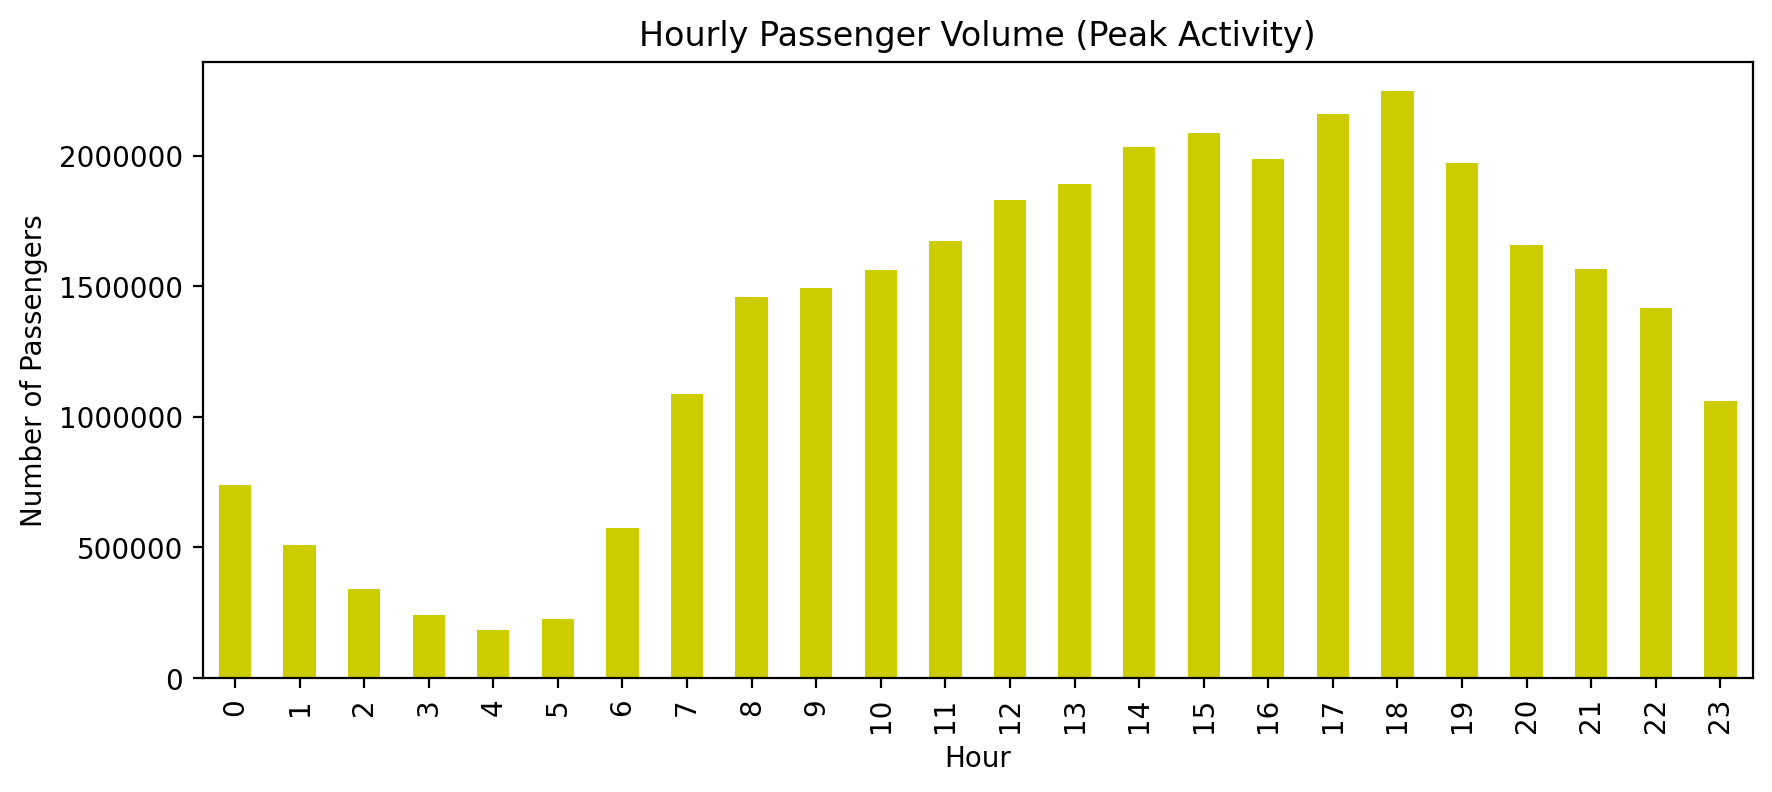

In [69]:
nytaxi['hour'] = nytaxi['tpep_pickup_datetime'].dt.hour

hourly_activity = (
    nytaxi.groupby('hour')['passenger_count']
      .sum()
)

plt.figure(figsize=(10,4), dpi=200)
hourly_activity.plot(kind='bar', color='#cccc00')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Hourly Passenger Volume (Peak Activity)')
plt.xlabel('Hour')
plt.ylabel('Number of Passengers')
plt.show()


* The hourly bar chart of passenger volume provides a clear view of how demand varies across different times of the day. Passenger counts are lowest during the early morning hours, particularly between 2 AM and 5 AM, and begin to rise sharply after 6 AM. Demand remains high throughout the daytime and peaks during the late afternoon and early evening hours, before gradually declining at night. The large differences in passenger volume between early morning and peak hours indicate that pickup time of day plays a significant role in determining passenger activity. This chart identifies the specific hours associated with peak and off-peak demand, complementing the decomposition analysis by showing where, in the daily cycle, passenger activity is concentrated.

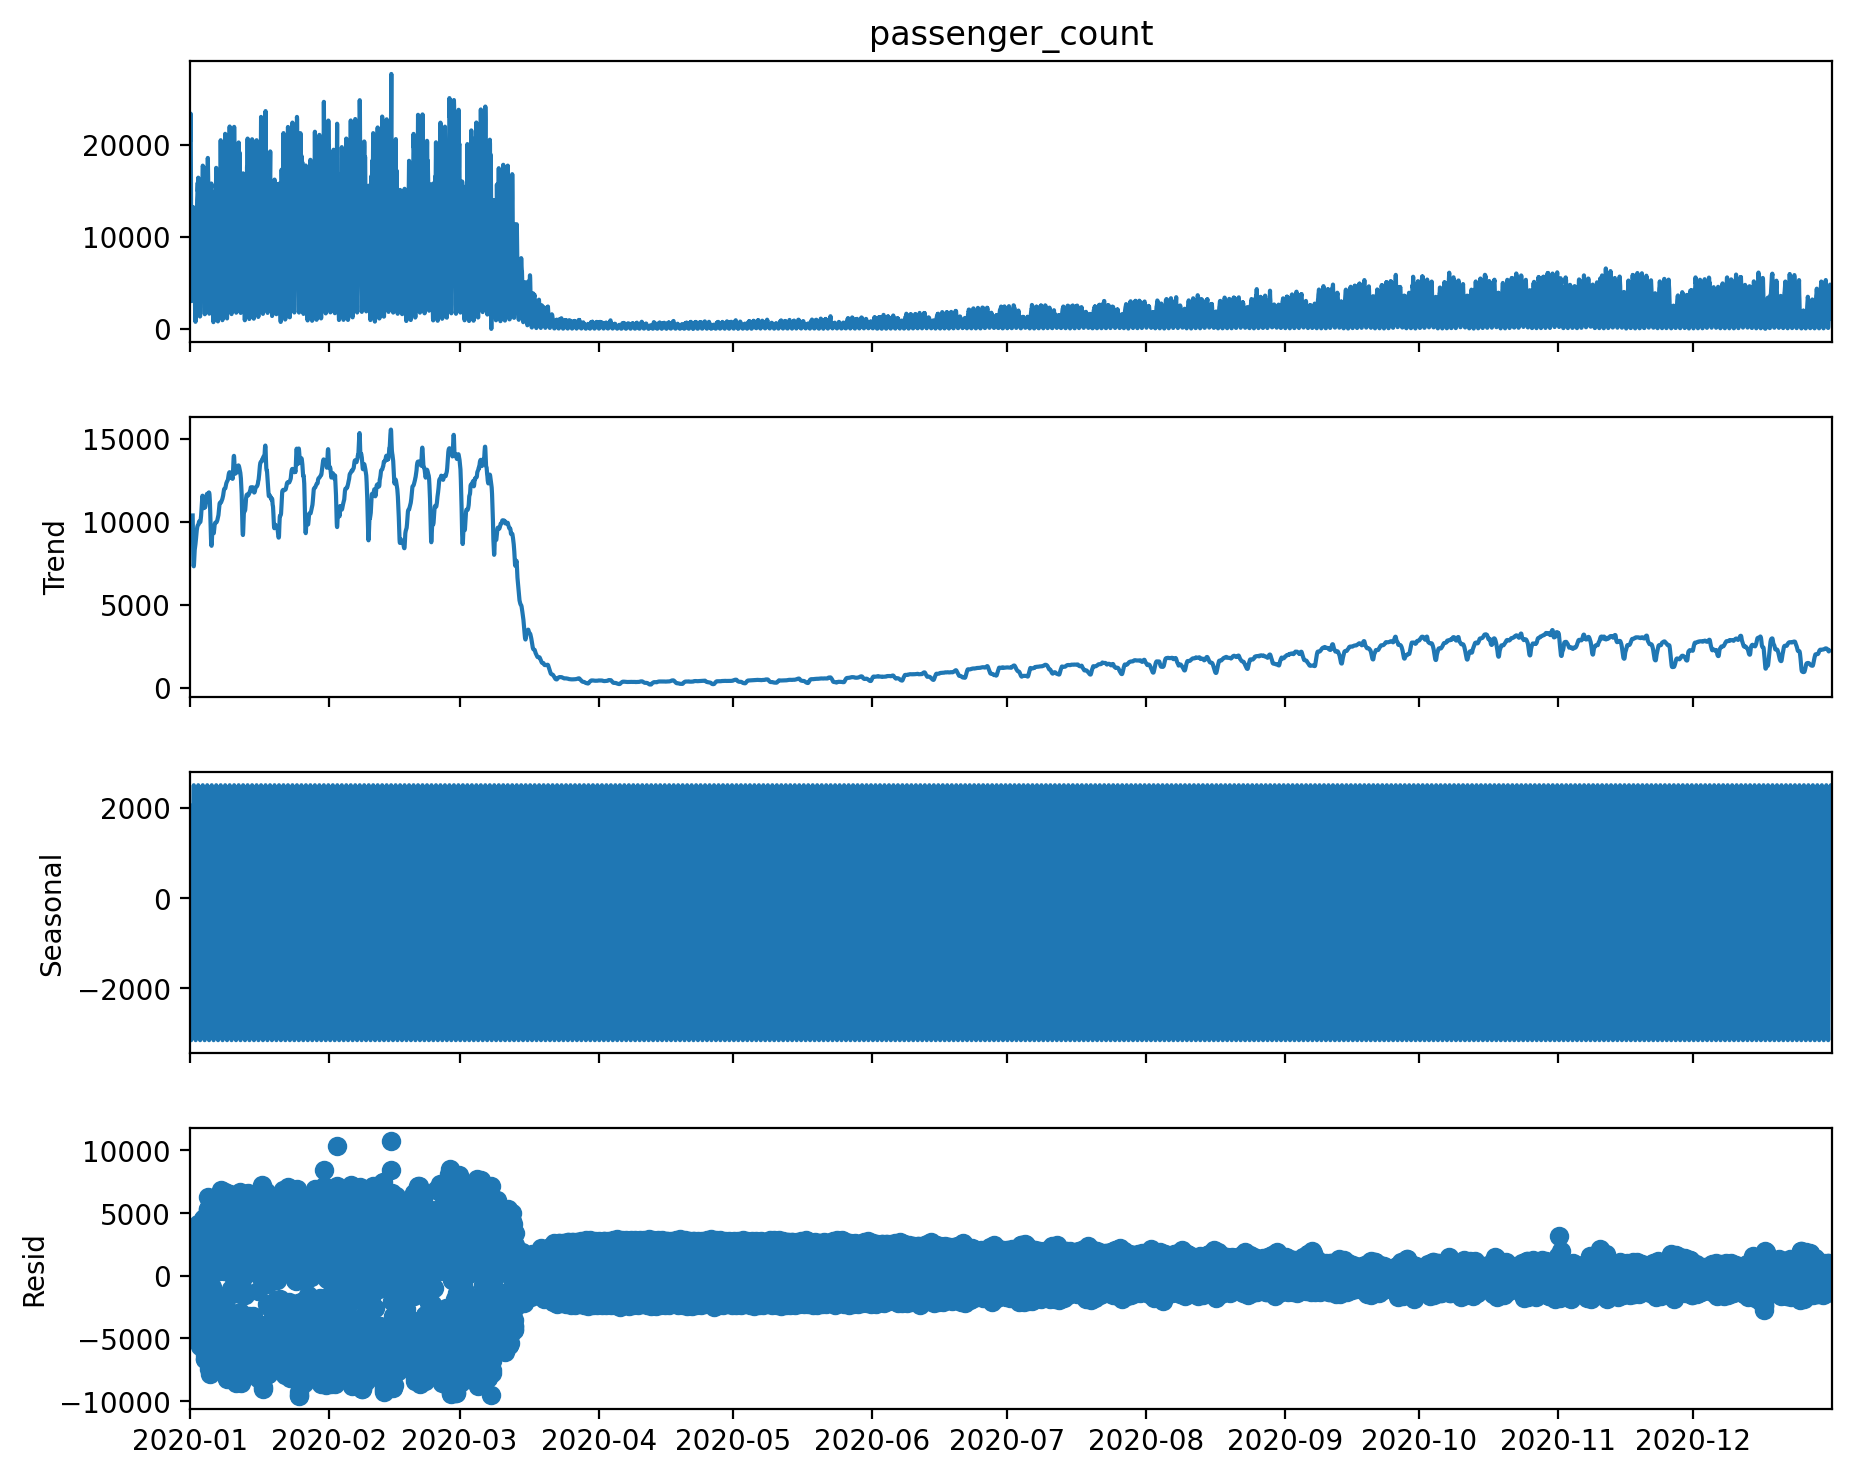

In [70]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

hourly_ts = (
    nytaxi
    .set_index('tpep_pickup_datetime')
    ['passenger_count']
    .resample('H')
    .sum()
)

decomp = seasonal_decompose(
    hourly_ts,
    model='additive',
    period=24,

)

fig = decomp.plot()
fig.set_size_inches(10, 8)
fig.set_dpi(200)


plt.show()


* The trend component shows a sharp drop in passenger volume around March 2020, followed by a slow recovery, highlighting the impact of a major external shock on taxi demand. Meanwhile, the seasonal component remains strong and stable, displaying a clear 24-hour cycle with consistent deviations from the mean. Even during periods of reduced demand, this daily pattern persists, indicating that time of day has a predictable effect on passenger volume. The residuals show irregular, non-repeating fluctuations, suggesting that the main temporal patterns are well captured by the trend and seasonal components.

#### 4. Which pickup locations have the highest passenger volume and trip activity?

In [71]:
summary_pickid = (
    nytaxi
    .groupby('PULocationID')['passenger_count']
    .agg(['count', 'mean', 'std'])
    .sort_values('mean', ascending=False)
)

print('Location with trip volume')
pd.DataFrame(
    summary_pickid['count']
    .sort_values(ascending=False)
    .head(3)
)


Location with trip volume


,count
PULocationID,
237,1087883
236,1034497
161,899592


In [72]:
summary_passengers = (
    nytaxi
    .groupby('PULocationID')['passenger_count']
    .sum()
    .sort_values(ascending=False)
    .head(3)
)
pd.DataFrame(summary_passengers)

,passenger_count
PULocationID,
237,1509408
236,1440499
161,1267370


* Among the 265 pickup locations, locations 237, 236, and 161 recorded the highest total passenger counts. These locations also had the highest numbers of trips, indicating that they are the most active pickup zones in terms of both trip frequency and passenger volume.

#### 5. Does passenger count differ by time of day (morning vs evening)?

In [73]:
from scipy.stats import mannwhitneyu

morning = nytaxi.loc[nytaxi['hour'].between(6, 11), 'passenger_count']
evening = nytaxi.loc[nytaxi['hour'].between(16, 21), 'passenger_count']

statistic, pvalue = mannwhitneyu(morning, 
                                 evening, 
                                 alternative='two-sided')

print('Results of Mann-Whitney U test')

mannwhitney = pd.DataFrame([{
    "Morning Median passenger count": f"{morning.median()}",
    "Evening Median passenger count": f"{evening.median()}",
    "Statistic": f"{statistic}",
    "p-value": f"{pvalue}"
    
}])
mannwhitney.T


Results of Mann-Whitney U test


,0
Morning Median passenger count,1.0
Evening Median passenger count,1.0
Statistic,22355667035447.0
p-value,0.0


* The very small p-value (< 0.001) shows that the likelihood of seeing a difference this large by chance—assuming morning and evening trips have the same passenger-count distribution—is extremely low. As a result, the null hypothesis is rejected, and the distributions differ statistically. That said, given the very large sample size, practical significance matters more than the test statistic alone. While evening trips are more frequent, the typical number of passengers per trip is the same in both periods. The Mann–Whitney U test confirms a statistically significant difference, but identical medians suggest the effect comes from small shifts in the distribution rather than a meaningful change in typical passenger count.

#### 6. Are taxi trips on weekends associated with higher passenger counts than weekdays?

In [74]:

weekdays = nytaxi.loc[nytaxi['tpep_pickup_datetime'].dt.dayofweek < 5, 'passenger_count']
weekends = nytaxi.loc[nytaxi['tpep_pickup_datetime'].dt.dayofweek >= 5, 'passenger_count'] 


statistic, pvalue = mannwhitneyu(weekdays, 
                                 weekends, 
                                 alternative='two-sided')

print(f"Statistics: {statistic:}")
print(f"p-value: {pvalue:} ")
print(f"Weekdays Median: {weekdays.median()}")
print(f"Weekends Median: {weekends.median()}")

print(f"Weekdays Mean: {weekdays.mean().round(3)}")
print(f"Weekends Mean: {weekends.mean().round(3)}")

Statistics: 45668460645973.0
p-value: 0.0 
Weekdays Median: 1.0
Weekends Median: 1.0
Weekdays Mean: 1.384
Weekends Mean: 1.471


* The p-value indicates that the passenger count distributions for weekdays and weekends are statistically different. Because the NYC taxi dataset is extremely large, even small distributional differences can result in statistical significance.

* Although the median passenger count is the same for weekdays and weekends (median = 1), weekend trips have a slightly higher average passenger count. This suggests that the typical taxi trip involves one passenger on both weekdays and weekends, but weekends exhibit more multi-passenger trips.

* The higher weekend mean passenger count (1.471) may reflect increased group travel, such as family trips, social outings, or shared leisure rides.

#### 7. Do passenger counts differ across boroughs (Midtown Center 161, Downtown Brooklyn 65, and JFK Airport 132)?

In [75]:
nytaxi['PULocationID'].isin([161,65,132]).sum()

1517584

In [76]:
from scipy.stats import kruskal

midtown_center_161 = nytaxi.loc[nytaxi['PULocationID'].isin([161]), 'passenger_count']
downtown_brooklyn_65 = nytaxi.loc[nytaxi['PULocationID'].isin([65]), 'passenger_count']
jfk_airport_132 = nytaxi.loc[nytaxi['PULocationID'].isin([132]), 'passenger_count']

statistic, pvalue = kruskal(midtown_center_161,
                           downtown_brooklyn_65,
                           jfk_airport_132,
                           )

print('Result of Kruskal-Wallis Test')
print(f"statistics: {statistic}")
print(f"P-Value: {pvalue}")
print(f"Median: {midtown_center_161.median()}")
print(f"Median: {downtown_brooklyn_65.median()}")
print(f"Median: {jfk_airport_132.median()}")

print(f"Mean: {midtown_center_161.mean()}")
print(f"Mean: {downtown_brooklyn_65.mean()}")
print(f"Mean: {jfk_airport_132.mean()}")

Result of Kruskal-Wallis Test
statistics: 1153.8851558312974
P-Value: 2.7354075179602385e-251
Median: 1.0
Median: 1.0
Median: 1.0
Mean: 1.4088275573815685
Mean: 1.3859920673309472
Mean: 1.4321115385774412


* The test shows a statistically significant difference across locations (H = 1153.89, p < 0.001), meaning the distributions are not identical. However, in practical terms, the differences are small: all three locations have a median passenger count of 1, and very similar averages, with JFK slightly higher, which fits expectations for airport trips. The extremely low p-value is largely driven by the huge sample size, making even subtle distributional differences detectable, such as a higher share of multi-passenger rides at certain locations. Overall, while the variation is statistically real, the effect size is modest and unlikely to have major operational impact.

In [77]:
from scikit_posthocs import posthoc_dunn
posthoc_dunn([midtown_center_161,
              downtown_brooklyn_65,
              jfk_airport_132],
              p_adjust='bonferroni')


,1,2,3
1,1.000000e+00,9.073740e-06,4.193387e-239
2,9.073740e-06,1.000000e+00,4.678081e-35
3,4.193387e-239,4.678081e-35,1.000000e+00


* The Kruskal–Wallis test indicated a statistically significant difference in passenger counts across boroughs (H = 1153.89, p < 0.001). Post-hoc Dunn’s tests with Bonferroni correction showed that all borough pairs differed significantly. JFK Airport exhibited the highest passenger counts and was the most distinct group, while Downtown Brooklyn had the lowest passenger counts.

#### 8. How do time of day and pickup location affect passenger count?

In [78]:
nytaxi['pickup_day'] = nytaxi['tpep_pickup_datetime'].dt.dayofweek
nytaxi['pickup_location'] = nytaxi['PULocationID']
nytaxi['pickup_location'] = nytaxi['pickup_location'].astype('category')
nytaxi['pickup_day'] = nytaxi['pickup_day'].astype('category')



loc_summary = (
    nytaxi
    .groupby(['pickup_location', 'pickup_day'])
    .agg(
        mean_passengers=('passenger_count', 'mean'),
        trips=('passenger_count', 'size')
       
    )
    .sort_values('mean_passengers', ascending=False)
)

loc_summary.head(3)

,,mean_passengers,trips
pickup_location,pickup_day,,
105,3,3.0,2
109,6,2.0,1
105,0,2.0,2


In [79]:
location, day = loc_summary['mean_passengers'].idxmax()
print(f"Location: {location} ")
print(f"Pickup day: {day} ")
print(f"Average number of Passenger: {loc_summary['mean_passengers'].max()} ")

Location: 105 
Pickup day: 3 
Average number of Passenger: 3.0 


* The results indicate that pickup location–day combinations, location 105 (Alphabet City, Lower East Side) shows its highest average passenger count on Thursdays, reaching a mean of 3.0 passengers per trip. While this is the largest observed location–day average in the data, further analysis would be required to determine whether Thursdays consistently attract higher passenger volumes at this location.

In [80]:
loc_overall = (
    nytaxi
    .groupby('pickup_location')
    .passenger_count
    .mean()
)

print(f"Location: {loc_overall.idxmax()}") 
print(f"Average Passenger: {loc_overall.max()}")


Location: 12
Average Passenger: 1.5896967482645232


+ When averaging passenger counts across all days of the week, pickup location 12 (Lenox Hill West, Manhattan) exhibits the highest mean passenger count per trip (≈ 1.59) among all pickup locations in the dataset.

In [81]:
day_overall = (
    nytaxi
    .groupby('pickup_day')
    .passenger_count
    .mean()
)

day_overall.idxmax(), day_overall.max()
print(f"Day of Week: {day_overall.idxmax()} ")
print(f"Average: {day_overall.max().round(3)} ")



Day of Week: 5 
Average: 1.479 


* When averaging across all pickup locations, Saturday emerges as the day of the week with the highest mean passenger count per trip (≈ 1.62). It suggests that trips on Saturdays tend to carry more passengers than those on other days.

*Averaging Passenger Count across all weekday*

In [82]:
day_summary = (
    nytaxi
    .groupby('pickup_day')
    .passenger_count
    .mean()
    .sort_values(ascending=False)
)
pd.DataFrame(day_summary)


,passenger_count
pickup_day,
5,1.479067
6,1.461531
4,1.403219
3,1.381644
2,1.381145
0,1.380448
1,1.371965


#### 9. Do longer trips tend to have more passengers?

In [83]:
import statsmodels.api as sm

X = sm.add_constant(nytaxi.trip_distance)
y = nytaxi.passenger_count

model_regression = sm.OLS(y,X).fit()

ci_low, ci_high = model_regression.conf_int().iloc[1]

summary_reg = pd.DataFrame([{
    'R-Squared': f"{model_regression.rsquared}",
    'Slop (coef)': f"{model_regression.params}",
    'slop p-value': f"{model_regression.pvalues}",
    "95% CI High" : f"{ci_high}",
    "95% CI Low": f"{ci_low}",
    "Condition Number": f"{model_regression.condition_number}"

}])
summary_reg.T

,0
R-Squared,0.00015996675810769911
Slop (coef),const 1.396693\ntrip_distance 0....
slop p-value,const 0.0\ntrip_distance 0.0\ndt...
95% CI High,0.0034066328077507033
95% CI Low,0.0031923058399661304
Condition Number,5.723123957534794


* The linear regression results indicate that there is no meaningful relationship between trip distance and passenger count. Although the estimated slope suggests that each additional unit of trip distance is associated with an increase of approximately 0.003 passengers, this effect is extremely small.

* While the coefficient is statistically significant (p < 0.001), the model’s R-squared value of 0.00016 indicates that trip distance explains only 0.016% of the variation in passenger count. Therefore, we conclude that longer trips do not meaningfully tend to have more passengers.

#### 10. Are higher passenger counts associated with higher fares?

In [84]:
import statsmodels.api as sm

X = sm.add_constant(nytaxi.fare_amount)
y = nytaxi.passenger_count

fare_reg = sm.OLS(y,X).fit()

ci_low, ci_high = fare_reg.conf_int().iloc[1]

fare_summary = pd.DataFrame([{
    "R-Squared": f"{fare_reg.rsquared}",
    "Slope (coef)": f"{fare_reg.params}",
    "Slope p-value":f"{fare_reg.pvalues}",
    "95% High CI": f"{ci_high:.7f}",
    "95% Low CI": f"{ci_low:.7f}",
    "Condition Number": f"{fare_reg.condition_number:.4f}"    
}])

fare_summary.T

,0
R-Squared,8.64171671184355e-05
Slope (coef),const 1.396139\nfare_amount 0.0007...
Slope p-value,const 0.0\nfare_amount 0.0\ndtype:...
95% High CI,0.0008250
95% Low CI,0.0007551
Condition Number,24.4322


* Although passenger count shows a statistically significant positive relationship with fare amount, the effect is extremely small and explains virtually none of the variation in fares. The near-zero p-value is mainly a result of the very large sample size, not a meaningful real-world relationship. In practice, passenger count does not help predict fare price, which aligns with NYC taxi pricing rules where fares are driven by distance and time, not the number of passengers.

#### 11. Is passenger count independent of pickup borough?

In [85]:
from scipy.stats import chi2_contingency

chi_squared_crosstab = pd.crosstab(
    nytaxi.passenger_count,
    nytaxi.PULocationID   
)

chi2_stat, p_value, dof, expected = chi2_contingency(chi_squared_crosstab)

simple_size = chi_squared_crosstab.values.sum()

r, c = chi_squared_crosstab.shape
k = min(r, c)

cramers_v = np.sqrt(chi2_stat / (simple_size * (k - 1)))


chi_squared_summary = pd.DataFrame([{"Statistics": f"{chi2_stat:.5f}",
                                    "p-values": f"{p_value:}",
                                    "Degree of Freedom": f"{dof}",
                                     "Simple Size": f"{simple_size}",
                                     "Effect size": f"{cramers_v:.5f}"
}])

chi_squared_summary.T


,0
Statistics,61659.54591
p-values,0.0
Degree of Freedom,1044
Simple Size,22761013
Effect size,0.02602


* A chi-square test of independence showed a statistically significant association between passenger count and pickup location (χ² = 61,659.55, df = 1044, p < 0.001). However, the effect size was very small (Cramér’s V = 0.026). Therefore, indicates that the association is negligible and suggesting that passenger count is largely independent of pickup location in practical terms

#### 12. Do passenger count distributions differ between peak and off-peak hours?

In [86]:
nytaxi["hour"] = nytaxi["tpep_pickup_datetime"].dt.hour

nytaxi["is_peak"] = (
    nytaxi["hour"].between(7, 9) |
    nytaxi["hour"].between(16, 18)
)

peak = nytaxi.loc[nytaxi["is_peak"], "passenger_count"].dropna()
offpeak = nytaxi.loc[~nytaxi["is_peak"], "passenger_count"].dropna()

from scipy.stats import mannwhitneyu

u, p = mannwhitneyu(
    peak,
    offpeak,
    alternative="two-sided"
)

print(f"Statistic: {u}")
print(f"p_value: {p}")
print("Peak median:", peak.median())
print("Off-peak median:", offpeak.median())

Statistic: 56226552762132.0
p_value: 0.0
Peak median: 1.0
Off-peak median: 1.0


In [87]:
print("Proportion of Peak")
print(peak.value_counts(normalize=True).sort_index())
print("\nProportion of Offpeak")

print(offpeak.value_counts(normalize=True).sort_index())

Proportion of Peak
passenger_count
1    0.778518
2    0.137025
3    0.036736
4    0.015754
5    0.031967
Name: proportion, dtype: Float64

Proportion of Offpeak
passenger_count
1    0.758903
2    0.151109
3    0.038885
4    0.017695
5    0.033409
Name: proportion, dtype: Float64


* A Mann–Whitney U test was used to compare passenger counts during peak and off-peak hours and found a statistically significant difference (p < 0.001). However, in practical terms, the two periods look almost identical: the median passenger count is 1 for both, and single-passenger trips dominate at about 76%, followed by two-passenger trips at roughly 15%. The significance is mainly driven by the very large sample size, with only small differences in the frequency of higher passenger counts. As a result, while the distributions are statistically different, the effect size is small and unlikely to be operationally meaningful.

#### 13. Has the average passenger count per trip changed over time?

In [88]:
import statsmodels.api as sm
import numpy as np

nytaxi = nytaxi.sort_values("tpep_pickup_datetime")


nytaxi["t"] = np.arange(len(nytaxi))

y = nytaxi["passenger_count"]
X = sm.add_constant(nytaxi["t"])

trend_reg = sm.OLS(y, X).fit()

ci_high, ci_low = trend_reg.conf_int().iloc[1]

trend_reg_summary = pd.DataFrame([{
    "R-Squared": f"{trend_reg.rsquared}",
    "Slope (coef)": f"{trend_reg.params}",
    "Slope p-value":f"{trend_reg.pvalues}",
    "95% High CI": f"{ci_high:.5f}",
    "95% Low CI": f"{ci_low:.5f}",
    "Condition Number": f"{trend_reg.condition_number:.4f}"    
}])

trend_reg_summary.T

,0
R-Squared,0.0018509824841814737
Slope (coef),const 1.472961e+00\nt -5.911091e-09\n...
Slope p-value,const 0.0\nt 0.0\ndtype: float64
95% High CI,-0.00000
95% Low CI,-0.00000
Condition Number,26282152.2331


* An OLS regression was used to test whether average passenger count has changed over time by regressing it on a numeric time index. The model finds a statistically significant negative trend (p < 0.001), but the effect is extremely small and not meaningful in practice. This is reinforced by the very low R² (around 0.002), showing that time explains almost none of the variation in passenger counts. Overall, while a slight downward trend is detectable statistically, average passenger occupancy has remained essentially stable over time.


#### 14. Are passenger counts higher in summer months than winter months?

In [89]:
from scipy.stats import mannwhitneyu

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Spring'
    else:
        return 'Fall'

nytaxi['season'] = nytaxi['tpep_pickup_datetime'].dt.month.apply(get_season)


winter = nytaxi.loc[nytaxi['season'] == 'Winter', 'passenger_count']
summer = nytaxi.loc[nytaxi['season'] == 'Summer', 'passenger_count']

u_stat, p_value = mannwhitneyu(winter, 
                               summer, 
                               alternative='two-sided')

print(f"H-statistic: {u_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Winter Mean: {winter.mean()}")
print(f"Winter Median: {winter.median()}")
print(f"Summer Mean: {summer.mean()}")
print(f"Summer Median: {summer.median()}")

H-statistic: 14463695833497.5000
p-value: 0.0000
Winter Mean: 1.4344476420777759
Winter Median: 1.0
Summer Mean: 1.3300534596634652
Summer Median: 1.0


* A Mann–Whitney U test was used to compare passenger counts per trip between winter and summer. The test produced a very large statistic and a p-value below 0.001, indicating a statistically significant seasonal difference. Descriptively, winter trips have a slightly higher average passenger count (1.43) than summer trips (1.33), while the median remains 1 in both seasons. This means most trips are single-passenger year-round, with multi-passenger rides occurring a bit more often in winter. Given the huge sample size, the result reflects a real but modest seasonal effect rather than a large practical difference.


## 7. Validation And Interpretation

### Practical significance

* We conducted statistical and non-statistical analyses on New York City yellow taxi data from 2020 to identify patterns, relationships, and trends. This exploration provided meaningful business insights and helped answer key business questions.

* For example, we found that passenger demand is lowest during the early morning hours, between 2 AM and 5 AM, and increases sharply after 6 AM. Demand continues to rise through the day, peaking in the late afternoon and early evening, before gradually declining at night. These peak and off-peak patterns reveal a clear daily cycle that helps identify when more taxis are needed and when demand is lower.

* Some findings are statistically significant and can support business decisions, while others, despite being statistically significant, have very small effects and may require further study to assess their practical value. For instance, passenger demand is higher in winter than in summer, suggesting more taxi use during colder months and indicating a greater need for taxis and drivers in winter

### Sensitivity Analysis

Sensitivity analysis plays an important role in this project by checking how robust and reliable the main findings are when assumptions or data choices change. This includes testing whether results around trip duration or fare drivers still hold when adjusting outlier thresholds, changing data filters, or excluding specific locations, payment types, or unusual time periods. If a predictive model is used, sensitivity analysis also looks at how small changes in inputs—such as trip distance, passenger count, or time of day—affect the predictions, helping identify which factors truly matter.

**Questions**

#### Are the results of tip amount and fare amount driven by unusually large tipping events?

In this step, we make some adjustments to our dataset. We noticed a few extreme values in both the tip and fare amounts. While these may seem like outliers, they actually represent rare but realistic cases. To keep things more balanced, we’ve limited the tip amount from 50 to 30 USD and adjusted the fare amount range from 2–300 USD down to 2–200 USD.

In [90]:
import statsmodels.api as sm

sensitive_analysis = nytaxi[['fare_amount', 'tip_amount', 'trip_distance']]
sensitive_analysis[sensitive_analysis['fare_amount'].between(2,200)]
sensitive_analysis[sensitive_analysis['tip_amount'].between(0,30)]


X = sm.add_constant(sensitive_analysis.fare_amount)
y = sensitive_analysis.tip_amount

sensitive_analysis_model = sm.OLS(y,X).fit()
ci_low, ci_high = sensitive_analysis_model.conf_int().iloc[1]

summary_model = pd.DataFrame( [{
    "Adj R-squared": f"{sensitive_analysis_model.rsquared:.4f}",
    "Slope (coef)" : f"{sensitive_analysis_model.params[1]}",
    "Slope p-value": f"{sensitive_analysis_model.pvalues[1]:.4f}",
    "95% CI (coef)" : f"[{ci_low:.4f}, {ci_high:.4f}]",
    "Condition No" : f"{sensitive_analysis_model.condition_number:.4f}"
    
}]).T
summary_model = (
    summary_model.rename_axis('Metrics')
    .set_axis(['Values'], axis=1)
)
print("Linear Regression Result")
summary_model

Linear Regression Result


,Values
Metrics,
Adj R-squared,0.2947
Slope (coef),0.12204030975562474
Slope p-value,0.0000
95% CI (coef),"[0.1220, 0.1221]"
Condition No,24.4322


**Interpretation**

* Fare amount is a statistically significant and economically meaningful predictor of tip amount. When the analysis is repeated on a restricted sample — limiting fares to 2–200 USD and tips to 0–30 USD — the results remain virtually unchanged, with nearly identical coefficient estimates, confidence intervals, and overall model fit. This suggests that the relationship between fare and tip amount is highly robust. Therefore, their relationship is  not driven by a small number of unusually large fares or tipping amounts. Although high-value observations reflect real-world behavior, they do not appear to have a disproportionate influence on the estimated relationship.

#### What changes if the analysis is restricted to typical ranges of fare amount and trip distance?

* We noticed a few extreme values in both the fare amounts and trip distance. These may seem like outliers, but they actually represent realistic cases. To keep things more balanced, we’ve limited the fare amount from 2 to 200 USD and restrict the trip distance to 1–70 miles.

In [91]:
 sensitive_analysis_trip = sensitive_analysis[sensitive_analysis['trip_distance'].between(1,70)]

import statsmodels.api as sm

X = sm.add_constant(sensitive_analysis_trip['fare_amount']) 
y = sensitive_analysis_trip['trip_distance']

sensitive_analysis_model = sm.OLS(y, X).fit()

ci_low, ci_high = sensitive_analysis_model.conf_int().iloc[1]

sensitive_analysis_summary = pd.DataFrame([{
    "Adjusted R²": f"{sensitive_analysis_model.rsquared_adj:.4f}",
    "Slope (coef)": f"{sensitive_analysis_model.params[1]:.4f}",
    "Slope p-value": f"{sensitive_analysis_model.pvalues[1]:.4f}", 
    "95% CI (slope)": f"[{ci_low:.4f}, {ci_high:.4f}]", 
    "Condition No": f"{sensitive_analysis_model.condition_number:.2f}" }]).T

sensitive_analysis_summary = (
    summary_lin_reg.rename_axis('Metrics')
    .set_axis(['Values'], axis=1)
)
sensitive_analysis_summary


,Values
Metrics,
Adjusted R²,0.7718
Slope (coef),0.2370
Slope p-value,0.0000
95% CI (slope),"[0.2369, 0.2370]"
Condition No,37.72


**Interpretation**

* Trip distance shows a clear and statistically strong relationship with the total fare charged. When we focus on more typical trips—those with fares between 2 and 200 USD and distances between 1 and 70 miles—we get almost the same results for the coefficients, model fit, and significance levels. This suggests that the link between distance and total fare is very robust and isn’t driven by a few extreme, but valid, trips. 

### Robustness Checks

To make sure our results weren’t being driven by extreme or unusual trips, we ran a sensitivity check by tightening the data ranges. We limited fares to 2–200 USD, trip distances to 1–70 miles, and tips to 0–30 USD, excluding rare but valid outliers while still keeping the data representative of typical NYC taxi trips. After re-running both models with these restrictions, the results stayed essentially the same—coefficients, model fit, and statistical significance showed no meaningful changes. This confirms that the findings are robust and stable, and that the observed relationships reflect genuine patterns in real-world NYC taxi fares rather than being driven by a small number of extreme cases.

## 8. Discussion And Limitations

* The results highlight several clear patterns in NYC Yellow Taxi operations during 2020. Passenger demand dropped sharply early in the year and then slowly recovered, reflecting the impact of the COVID-19 pandemic. Even with this disruption, daily pickup patterns stayed remarkably consistent, showing that time of day continued to play a predictable role in taxi usage. Fare amounts were also strongly right-skewed, with most trips falling in the low to mid range and a small number of high-fare trips creating a long tail—exactly what you’d expect in a city dominated by short rides with occasional long or airport trips.

* That said, there are a few important limitations to keep in mind. The analysis only uses Yellow Taxi data and does not include ride-hailing services like Uber or Lyft, which became more popular during this period. Since 2020 was an unusual year, these results may not fully reflect typical travel patterns. While outliers were reviewed and robustness checks were applied, some extreme but valid values may still affect the results. Finally, because the analysis is observational, the relationships identified should be interpreted as associations rather than causal effects.


## 9. Conclusion

This project demonstrates that even during one of the most disruptive years in modern urban history, NYC Yellow Taxi data still exhibits clear structure, predictable patterns, and statistically meaningful relationships. Passenger behavior remained strongly tied to time of day, fares were driven by trip distance and passenger count, and the overall fare system showed resilience despite reduced demand. These insights reinforce the value of high-frequency transportation data for understanding urban mobility, especially during periods of crisis. Future work could expand this analysis by incorporating multiple years of data, comparing Yellow Taxis to ride-hailing services, or exploring spatial patterns in greater depth.

## 10. References
New York City Government. *TLC Trip Record Data*. Retrieved from:

https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page